In [27]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class DeepUNet(nn.Module):
    def __init__(self, in_ch=4, out_ch=1):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(in_ch, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)
        self.enc5 = DoubleConv(256, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up5 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec5 = DoubleConv(1024, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e5 = self.enc5(self.pool(e4))

        # Bottleneck
        b = self.bottleneck(self.pool(e5))

        # Decoder
        d5 = self.up5(b)
        d5 = self.dec5(torch.cat([d5, e5], dim=1))

        d4 = self.up4(d5)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)


In [28]:
test = torch.randn([1, 4, 256 ,256])
model = UNetSimple()
model(test).shape

torch.Size([1, 1, 256, 256])

In [29]:
activations = {}
pool_count = 0

def get_activation(name):
    def hook(model, input, output):
        global pool_count

        if name == "pool":
            key = f"pool_{pool_count}"
            activations[key] = output.detach().cpu()
            pool_count += 1
        else:
            activations[name] = output.detach().cpu()

    return hook



for name, layer in model.named_modules():
    if isinstance(layer,(nn.Conv2d, nn.ConvTranspose2d, nn.MaxPool2d)):
        layer.register_forward_hook(get_activation(name))

out = model(test)


In [30]:
names = list(activations.keys())

for i,n in enumerate(names):
    print(i,n)


0 enc1.conv.0
1 enc1.conv.2
2 pool_0
3 enc2.conv.0
4 enc2.conv.2
5 pool_1
6 enc3.conv.0
7 enc3.conv.2
8 pool_2
9 bottleneck.conv.0
10 bottleneck.conv.2
11 up3
12 dec3.conv.0
13 dec3.conv.2
14 up2
15 dec2.conv.0
16 dec2.conv.2
17 up1
18 dec1.conv.0
19 dec1.conv.2
20 out_conv


In [31]:
activations[names[0]].shape, activations[names[1]].shape , activations[names[2]].shape

(torch.Size([1, 32, 256, 256]),
 torch.Size([1, 32, 256, 256]),
 torch.Size([1, 32, 128, 128]))

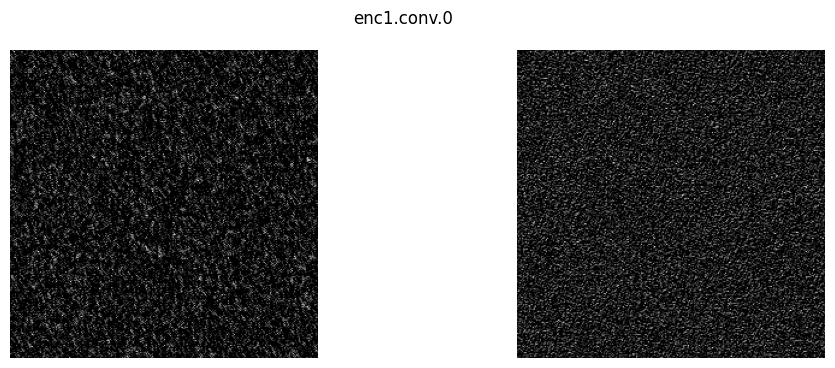

In [32]:
import matplotlib.pyplot as plt

for name, act in activations.items():

    feature_maps = act[0]   
    num_maps = min(2, feature_maps.shape[0])

    plt.figure(figsize=(12,4))
    plt.suptitle(name)

    for i in range(num_maps):
        plt.subplot(1, num_maps, i+1)
        plt.imshow(feature_maps[i], cmap='gray')
        plt.axis("off")

    plt.show()
    break


In [33]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import numpy as np
import os

class HologramDataset(Dataset):
    def __init__(self, root_dir: str):
        self.pathes = [
            os.path.join(root_dir, sample) for sample in os.listdir(root_dir)
        ]

    def __len__(self):
        return len(self.pathes)

    def __getitem__(self, idx):
        img_obj = np.load(self.pathes[idx])

        holo_list = np.stack([img for name, img in img_obj.items() if name != 'GT'])
        holo_list = torch.from_numpy(holo_list).float()   # [C,H,W]

        GT = torch.from_numpy(img_obj['GT']).float().unsqueeze(0)  # [1,H,W]

        # add batch dim for interpolate
        holo_list = holo_list.unsqueeze(0)
        GT = GT.unsqueeze(0)

        holo_list = F.interpolate(holo_list, size=(256,256), mode='bilinear', align_corners=False)

        # remove batch dim
        holo_list = holo_list.squeeze(0)
        GT = GT.squeeze(0)

        return holo_list , GT


In [34]:
train_dataset = HologramDataset(r'transform_output\train')
val_dataset = HologramDataset(r'transform_output\val')
# train_dataset[0][0].shape , train_dataset[0][1].shape
# val_dataset[0][0].shape , val_dataset[0][1].shape
train_dataset[0][0].shape , train_dataset[0][1].shape

(torch.Size([4, 256, 256]), torch.Size([1, 256, 256]))

In [35]:
# class ImageDataset(Dataset):
#     def __init__(self, inputs_path, target_path, target_size=(512, 512)):
#         self.inputs_path = inputs_path
#         self.target_path = target_path
#         self.target_size = target_size
#         self.transform = transforms.ToTensor()

#         # Load target once
#         t_img = Image.open(self.target_path).convert('L')
#         t_img = t_img.resize(self.target_size, Image.LANCZOS)
#         self.target_tensor = self.transform(t_img)

#     def __len__(self):
#         return len(self.inputs_path)

#     def __getitem__(self, index):
#         x_path = self.inputs_path[index]
#         x_image = Image.open(x_path).convert('L')
#         x_image = x_image.resize(self.target_size, Image.LANCZOS)
#         x_tensor = self.transform(x_image)
#         y_tensor = self.target_tensor
#         return x_tensor, y_tensor

In [36]:
from torch.utils.data import random_split, DataLoader

val_size = len(val_dataset)
test_size = val_size // 4
new_val_size = val_size - test_size

val_ds, test_ds = random_split(val_dataset, [new_val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds, batch_size=4, shuffle=False, drop_last=False)

len(train_loader)*4, len(val_loader)*4, len(test_loader)*4


(100, 24, 8)

In [37]:
# import os

# # Paths
# inputs_path = [
#     'quantom_dataset/train/train1.png',
#     'quantom_dataset/train/train2.png',
#     'quantom_dataset/train/train3.png'
# ]
# target_path = 'quantom_dataset/target/ground_truth.png'

# # Dataset and DataLoader
# dataset = ImageDataset(inputs_path, target_path, target_size=(512, 512))
# dataloader = DataLoader(dataset, batch_size=3, shuffle=False)

# # Device and model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNetSimple(in_ch=4, out_ch=1).to(device)

# # Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.L1Loss()

# print(f"Device: {device}")
# print(f"Dataset size: {len(dataset)}")

In [38]:
for holos , gt in train_loader : 
    print(holos.shape , gt.shape)
    break

torch.Size([4, 4, 256, 256]) torch.Size([4, 1, 256, 256])


In [39]:
model.train()
num_epochs = 2
loss_history = []

from tqdm import tqdm
from pytorch_msssim import ms_ssim

number_of_epoch = 15 
criterion_mse = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters() , lr=0.001 ,  weight_decay=0.0005, amsgrad=True)


class NPCCLoss(nn.Module):
    def __init__(self):
        super(NPCCLoss, self).__init__()

    def forward(self, pred, target):
        B = pred.shape[0] # 4

        pred = pred.view(B, -1) # (4, 1*256*256)
        target = target.view(B, -1)#(4, 1 * 256*256)

        pred_mean = pred.mean(dim=1, keepdim=True) # (batch,1) 1 is mean
        target_mean = target.mean(dim=1, keepdim=True)

        pred_centered = pred - pred_mean # x-xpred
        target_centered = target - target_mean # y-ypred

        numerator = torch.sum(pred_centered * target_centered, dim=1) # covariance of x and y

        denominator = torch.sqrt( 
            torch.sum(pred_centered ** 2, dim=1) *
            torch.sum(target_centered ** 2, dim=1)
        )

        pcc = numerator / (denominator + 1e-8) # normalized covariance -1 to 1

        loss = -torch.mean(pcc) # [pcc1 , pcc2 .. pcc4] mean of all covariance 

        return loss


def ms_ssim_loss(pred, target):
    return 1 - ms_ssim(pred, target, data_range=1, size_average=True)

npcc_loss = NPCCLoss()

def calculate_loss(predict, gt): 
        loss_mse = criterion_mse(predict, gt)
        loss_npcc = npcc_loss(predict, gt)
        loss_ssim = ms_ssim_loss(predict, gt)
        loss = 4*loss_mse + loss_ssim + loss_npcc
        return loss

total_train_loss = []
total_val_loss = []
patience = 20
early_counter =0 
best_loss = float('inf')
for epoch in tqdm(range(num_epochs)):
    epoch_losses = []
    
    current_loss = float('inf')
    patience = 50 
    patience_counter = 0

    for holos ,gt in train_loader:
        holos, gt = holos.to(device), gt.to(device)
        optimizer.zero_grad()
        output = model(holos)
        loss = calculate_loss(output, gt)
        
        epoch_losses.append(loss.item())
        loss.backward()
        optimizer.step()
    
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)

    if avg_loss < current_loss : 
        current_loss = avg_loss 
        torch.save({
            'model_state_dict': model.state_dict(),
            'loss_history': loss_history
        }, 'checkpoint.pth')
    else : 
        patience_counter +=1 
        if patience_counter >= patience : 
            print('early stop triggered')
            break 
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

# Save model
torch.save(model.state_dict(), 'simple_unet_model.pth')
print("Model saved!")

100%|██████████| 2/2 [00:44<00:00, 22.15s/it]

Model saved!


In [40]:
model.load_state_dict(torch.load('simple_unet_model.pth'))


<All keys matched successfully>

In [41]:
import cv2 as cv
import numpy as np
import torch

def load_single_image(img_path, gt_path, transformer):

    img = cv.imread(img_path)
    result = transformer.transform(img)
    target = cv.imread(gt_path , cv.IMREAD_GRAYSCALE)
    target = cv.resize(target , (256 ,256))

    holo_seven = cv.imread('holo_seven.png', cv.IMREAD_GRAYSCALE)
    holo_seven = cv.resize(holo_seven, (512, 512))

    # shape -> [512,512]
    holos = np.stack([holo_seven]*4)   # [4,512,512]

    holo_list = torch.from_numpy(holos).float()
    holo_list = holo_list.unsqueeze(0)         # [1,4,512,512]

    GT = torch.from_numpy(target).float()
    GT = GT.unsqueeze(0)

    return GT, holo_list


In [42]:
from final import QIUPTransformer
transformer  = QIUPTransformer() 
result = load_single_image('holo_seven.png' ,'gt_7.png' , transformer=transformer)
holo_list = F.interpolate(result[1], size=(256,256), mode='bilinear', align_corners=False)
GT = result[0]
GT.shape , holo_list.shape

(torch.Size([1, 256, 256]), torch.Size([1, 4, 256, 256]))

In [43]:
model.eval()

gt_images = []
pred_images = []
test_input  = holo_list.to(device)
with torch.no_grad():
        gt = GT.to(device)
        test_pred = model(test_input)
        gt_images.append(gt.cpu())
        pred_images.append(test_pred.cpu())

activations = {}
pool_count = 0



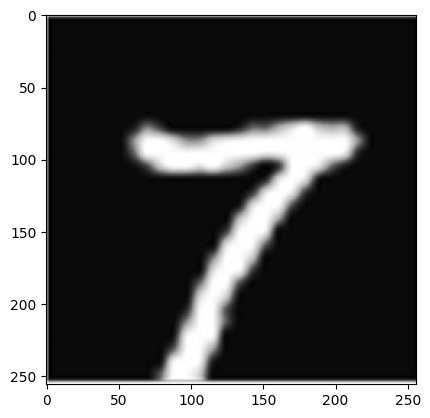

In [44]:
plt.imshow(gt_images[0].squeeze() , cmap='gray')

In [45]:
pred_images[0].min() , pred_images[0].max()

(tensor(-31.3882), tensor(0.9825))

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

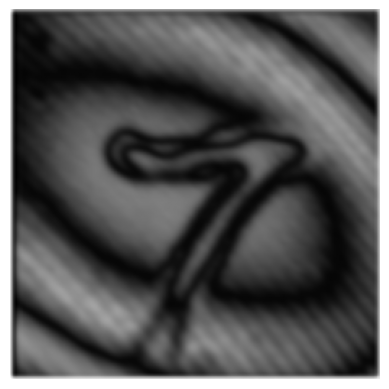

In [46]:
plt.imshow(pred_images[0].squeeze() , cmap='gray')
plt.axis('off')

In [ ]:
activations = {}
pool_count = 0

def get_activation(name):
    def hook(model, input, output):
        global pool_count

        if name == "pool":
            key = f"pool_{pool_count}"
            activations[key] = output.detach().cpu()
            pool_count += 1
        else:
            activations[name] = output.detach().cpu()

    return hook

for name, layer in model.named_modules():
    if isinstance(layer,(nn.Conv2d, nn.ConvTranspose2d, nn.MaxPool2d)):
        layer.register_forward_hook(get_activation(name))

model(test_input)

tensor([[[[ -0.3134,  -4.9731,  -9.4261,  ..., -10.3706,  -8.4098,  -5.2789],
          [ -1.1204,  -8.5744, -15.1451,  ..., -15.6592, -11.6473,  -6.5944],
          [ -3.0754, -12.7844, -20.8860,  ..., -19.8908, -14.3451,  -7.4907],
          ...,
          [ -2.5159, -11.9232, -19.2831,  ..., -16.4698, -11.7654,  -6.4611],
          [ -0.9958,  -6.4759, -11.7011,  ...,  -9.5397,  -6.0604,  -3.2750],
          [  0.9825,  -1.7011,  -3.8428,  ...,  -3.4557,  -1.9754,  -1.6031]]]],
       grad_fn=<ConvolutionBackward0>)

In [48]:
layer_name_list[10:]

NameError: name 'layer_name_list' is not defined

In [49]:
result = filter(lambda num: num , [0 , 0 ,1])
list(result)

[1]

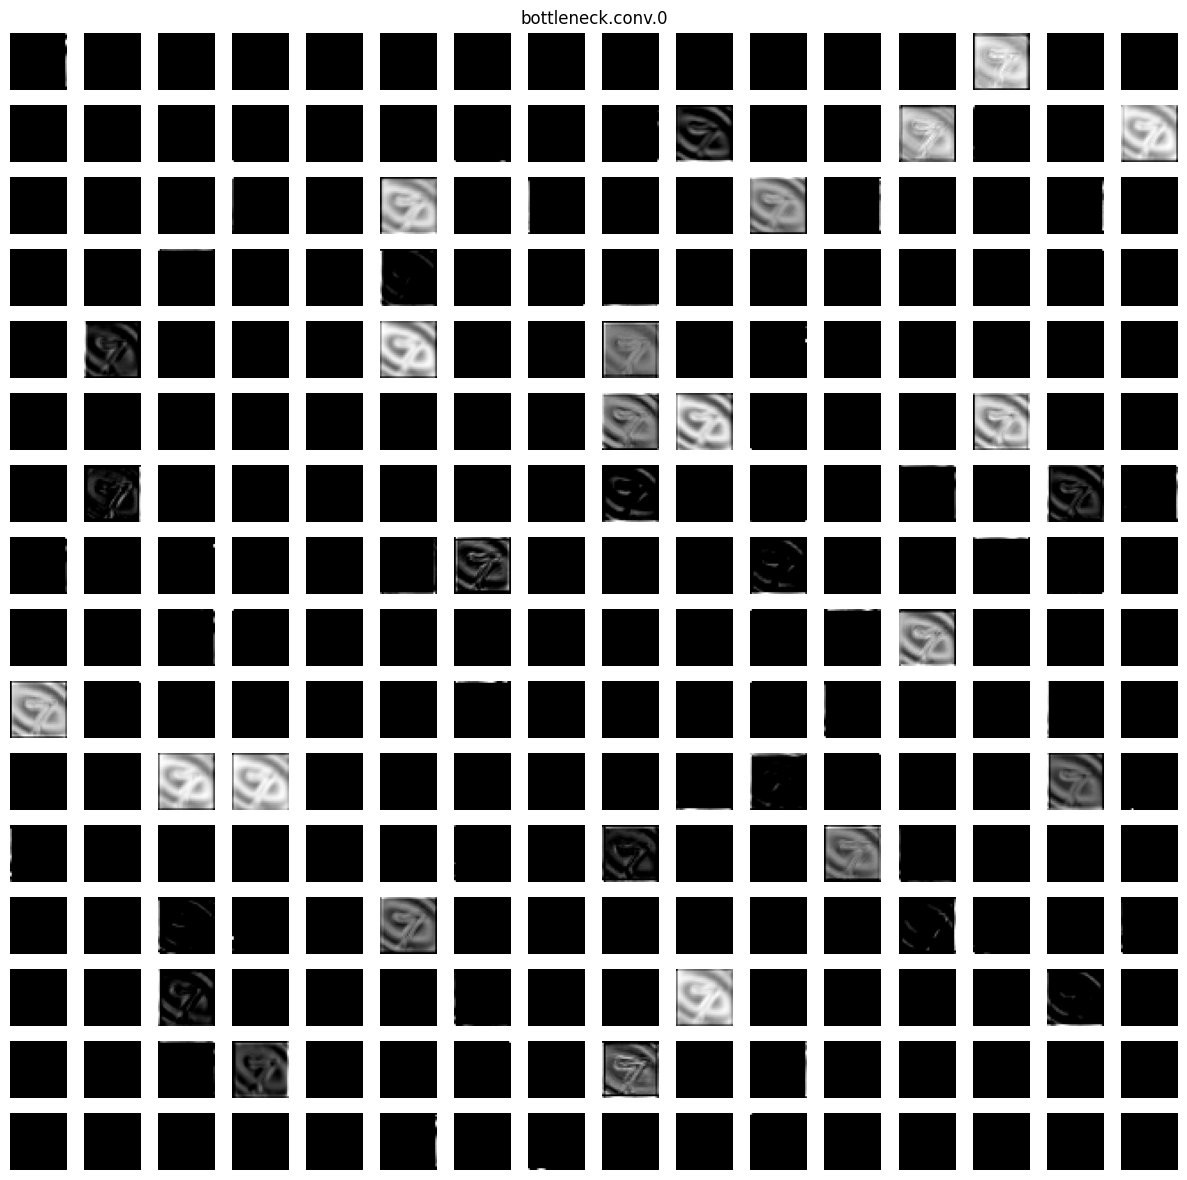

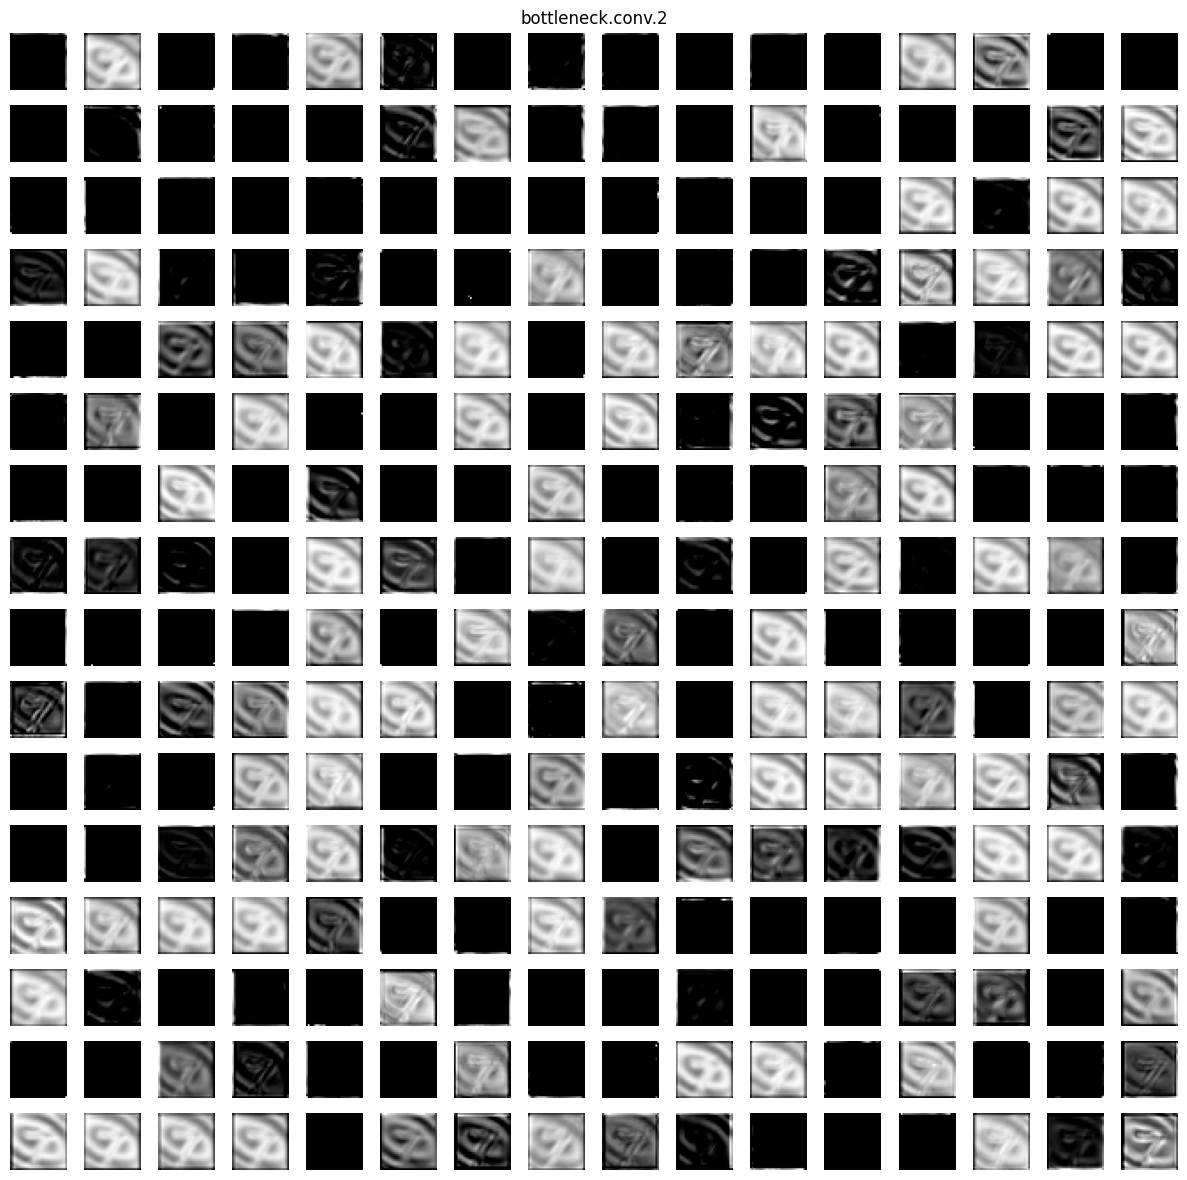

In [50]:
import matplotlib.pyplot as plt
import math

layers_to_show = ['bottleneck.conv.0', 'bottleneck.conv.2']

for layer_name in layers_to_show:

    act = activations[layer_name]

    fmap = act[0]
    C = fmap.shape[0]
    num = min(256, C)

    cols = int(math.ceil(math.sqrt(num)))
    rows = int(math.ceil(num / cols))

    plt.figure(figsize=(12,12))
    plt.suptitle(layer_name)

    for i in range(num):
        plt.subplot(rows, cols, i+1)
        plt.imshow(fmap[i], cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()



In [ ]:
image = r'C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\holo_sum_raw16.png'

